In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


In [2]:
df=pd.read_csv("/content/drive/MyDrive/Data Science/Dataset/usedCars (1).csv")

# EDA and Preprocessing

In [3]:
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


The dataset contains vehicle attributes used to predict used car prices.

In [4]:
df.tail()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
1059,588906,HYUNDAI,ELITE I20(2020-2020),ASTA O 1.2 BS VI,PETROL,White,42918,HATCHBACK,NaN,2020-09-01,2020,NaN,7.15 Lakhs,1st Owner,Rajasthan,K.S. Motors,Jaipur,1,8.3
1060,588945,HYUNDAI,XCENT(2017-2020),S,PETROL,White,78910,SEDAN,NaN,2019-01-01,2019,NaN,5.00 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,7.8
1061,588946,MAHINDRA,SCORPIO(2009-2014),VLX 2WD BS-III,DIESEL,White,76000,SUV,NaN,2013-05-01,2013,NaN,5.75 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,6.8
1062,588949,MARUTI SUZUKI,VITARA BREZZA,VDI,DIESEL,Silver,80120,HATCHBACK,NaN,2018-06-01,2018,NaN,7.71 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,7.4
1063,588950,HONDA,CITY,SV MT DIESEL,DIESEL,Urban Titanium,77500,SEDAN,Manual,2014-01-01,2014,NaN,4.99 Lakhs,2nd Owner,Rajasthan,Rajasthan Car World,Jaipur,0,6.8


The final records confirm the dataset is consistently structured and ready for analysis.

In [5]:
df.shape

(1064, 19)

The dataset contains 979 records and 12 features, making it suitable for price prediction analysis.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


The dataset contains both numerical and categorical features with appropriate data types.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1064.0,568156.542293,16438.139974,525978.0,555321.5,572753.0,583072.75,589122.0
Kilometer,1064.0,52807.187970,33840.296979,101.0,32113.5,49432.0,68828.50,640000.0
ModelYear,1064.0,2016.864662,2.996786,2003.0,2015.0,2017.0,2019.00,2023.0
Warranty,1064.0,0.738722,0.439538,0.0,0.0,1.0,1.00,1.0
QualityScore,1064.0,7.770207,0.719717,0.0,7.5,7.8,8.10,9.4


The statistical summary provides an overview of the distribution, central tendency, and variability of numerical features.

In [8]:
df.dtypes

,0
Id,int64
Company,object
Model,object
Variant,object
FuelType,object
Colour,object
Kilometer,int64
BodyStyle,object
TransmissionType,object
ManufactureDate,object


The dataset contains both numerical and categorical data types for analysis and modeling.

In [9]:
df.isnull().sum()

,0
Id,0
Company,0
Model,0
Variant,0
FuelType,1
Colour,0
Kilometer,0
BodyStyle,0
TransmissionType,714
ManufactureDate,0


No missing values were found, indicating a complete dataset.

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found, ensuring data uniqueness.

In [11]:
df['Price']

,Price
0,5.75 Lakhs
1,4.35 Lakhs
2,4.7 Lakhs
3,9.9 Lakhs
4,2.7 Lakhs
...,...
1059,7.15 Lakhs
1060,5.00 Lakhs
1061,5.75 Lakhs
1062,7.71 Lakhs


In [12]:
def convert_price(price):

    price = str(price).lower().replace(",", "").strip()

    if "lakh" in price:
        return float(price.replace("lakhs","").replace("lakh",""))*100000

    elif "crore" in price:
        return float(price.replace("crores","").replace("crore",""))*10000000

    else:
        return float(price)

df["Price"] = df["Price"].apply(convert_price)

The Price column is converted into a consistent numeric format, enabling accurate analysis and model training.

In [13]:
#Convert Date Column
df['ManufactureDate']=pd.to_datetime(df["ManufactureDate"])

In [14]:
#Create Car Age Feature
current_year=pd.Timestamp.now().year
df["CarAge"]=current_year-df["ManufactureDate"].dt.year

In [15]:
#Remove Manufacture Date
df.drop(["ManufactureDate","ModelYear"],axis=1,inplace=True)

In [16]:
df.drop("DealerName",axis=1,inplace=True)

In [17]:
df.drop("Variant", axis=1, inplace=True)

In [18]:
#Remove ID Column
if "Id" in df.columns:
  df.drop("Id",axis=1,inplace=True)

In [19]:
df.head()

,Company,Model,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,CngKit,Price,Owner,DealerState,City,Warranty,QualityScore,CarAge
0,MARUTI SUZUKI,CELERIO(2017-2019),PETROL,Silver,33197,HATCHBACK,NaN,NaN,575000.0,1st Owner,Karnataka,Bangalore,1,7.8,8
1,MARUTI SUZUKI,ALTO,PETROL,Red,10322,HATCHBACK,Manual,NaN,435000.0,1st Owner,Karnataka,Bangalore,1,8.3,5
2,HYUNDAI,GRAND I10,PETROL,Grey,37889,HATCHBACK,Manual,NaN,470000.0,1st Owner,Karnataka,Bangalore,1,7.9,11
3,TATA,NEXON,PETROL,A Blue,13106,HATCHBACK,NaN,NaN,990000.0,1st Owner,Karnataka,Bangalore,1,8.1,6
4,FORD,FIGO,DIESEL,Silver,104614,HATCHBACK,Manual,NaN,270000.0,2nd Owner,Karnataka,Bangalore,0,7.5,16


In [20]:
#Missing Value Treatment(Numeric)
numeric_columns=df.select_dtypes(include=np.number).columns
for col in numeric_columns:
  df[col].fillna(df[col].median(),inplace=True)

In [21]:
#Missing Value Treatment(categoric)
categorical_columns=df.select_dtypes(include="object").columns
for col in categorical_columns:
  df[col].fillna(df[col].mode()[0],inplace=True)

In [22]:
df.isnull().sum()

,0
Company,0
Model,0
FuelType,0
Colour,0
Kilometer,0
BodyStyle,0
TransmissionType,0
CngKit,0
Price,0
Owner,0


In [23]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()

In [24]:
print("Numerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Kilometer', 'Price', 'Warranty', 'QualityScore', 'CarAge']

Categorical Features
['Company', 'Model', 'FuelType', 'Colour', 'BodyStyle', 'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'City']


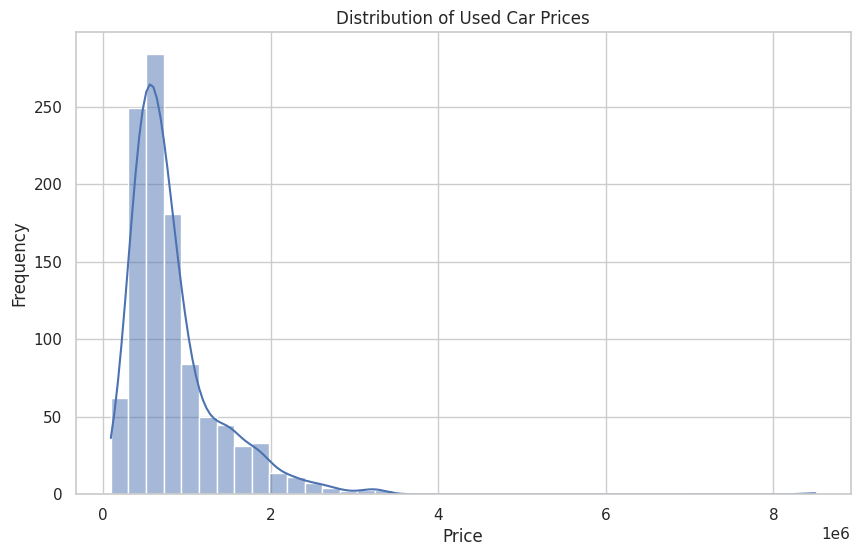

In [25]:
#price distribution
plt.figure(figsize=(10,6))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

The price distribution is right-skewed, with most used cars concentrated in the lower price range.

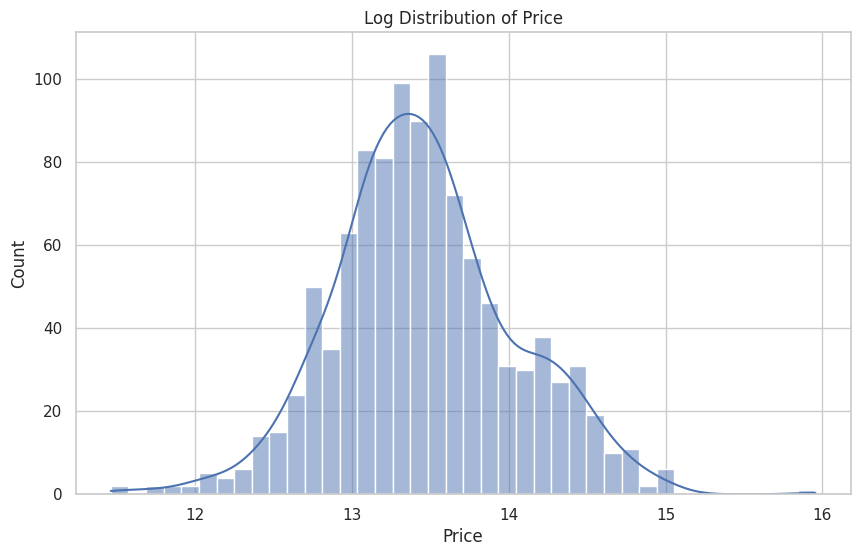

In [26]:
#Log Distribution of Price
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df["Price"]), bins=40, kde=True)
plt.title("Log Distribution of Price")

plt.show()

The log transformation reduces skewness, resulting in a more balanced distribution of car prices.

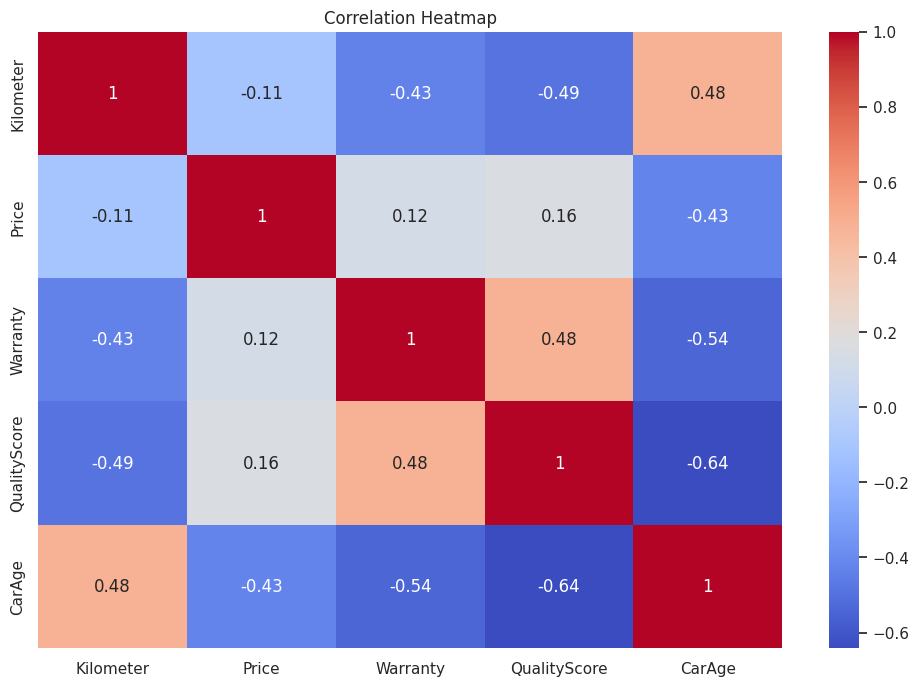

In [27]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.show()

The heatmap highlights the strength and direction of relationships among numerical features.

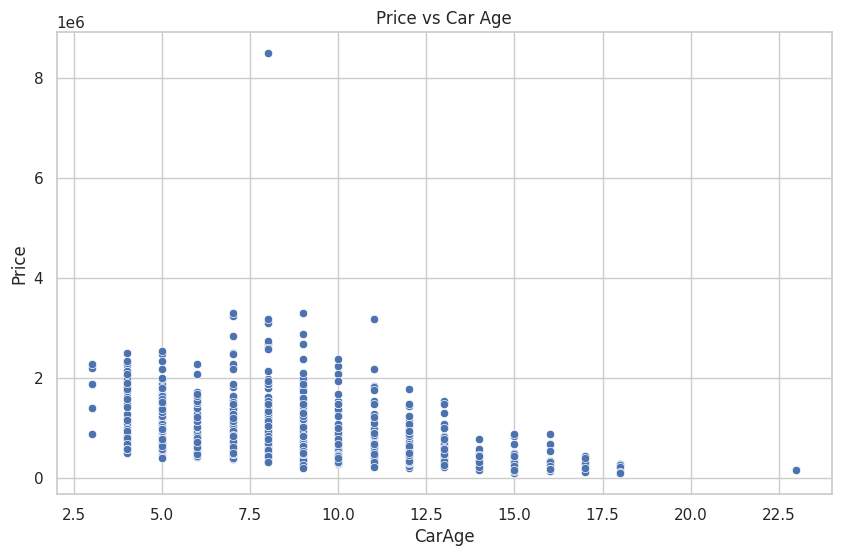

In [28]:
#Price vs Car Age
plt.figure(figsize=(10,6))

sns.scatterplot(x=df['CarAge'],y=df['Price'])
plt.title("Price vs Car Age")

plt.show()

Car prices generally decrease as vehicle age increases, indicating a negative relationship.

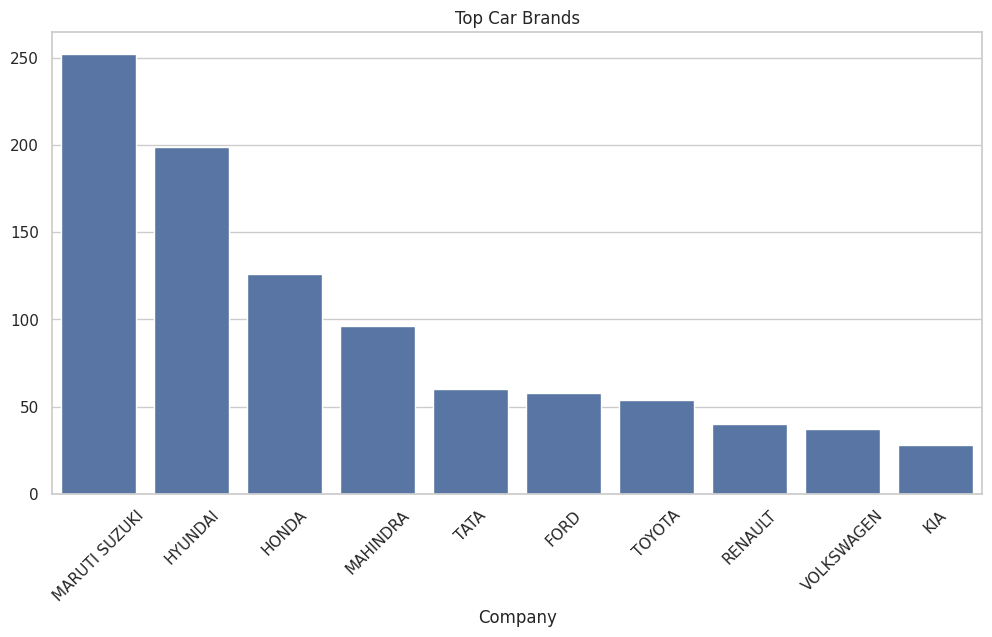

In [29]:
#Top 10 Brands
plt.figure(figsize=(12,6))
top_brand=df['Company'].value_counts().head(10)
sns.barplot(x=top_brand.index,y=top_brand.values)
plt.xticks(rotation=45)
plt.title("Top Car Brands")
plt.show()

The chart shows the most frequently listed car brands in the used car dataset.

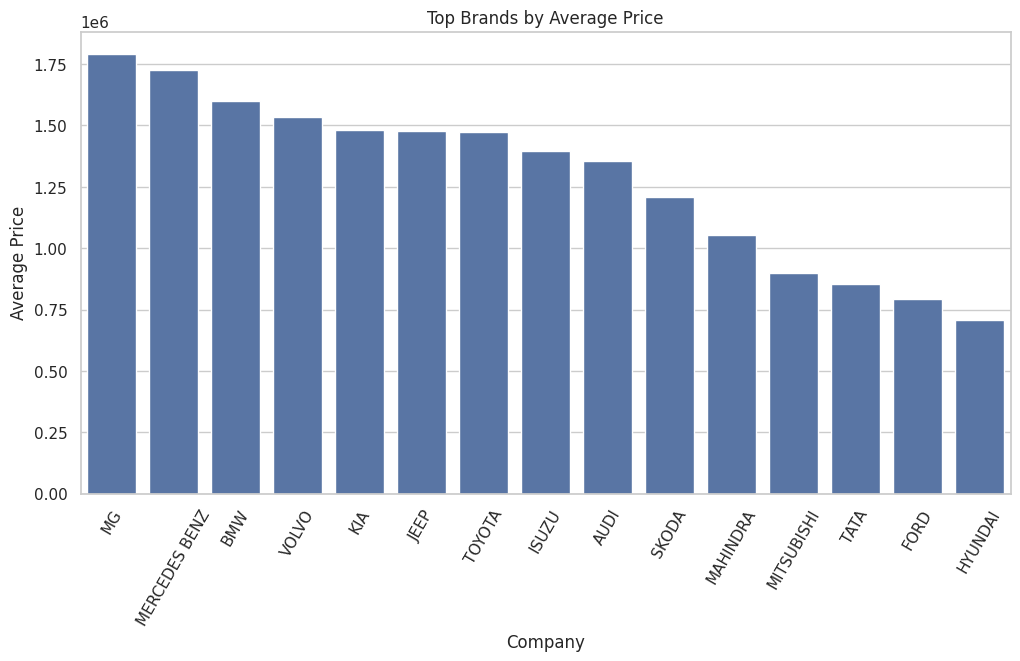

In [30]:
#Average Price by Brand
brand_price = (
    df.groupby("Company")["Price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=60)

plt.ylabel("Average Price")

plt.title("Top Brands by Average Price")

plt.show()

Premium car brands have a higher average resale price than mass-market brands.

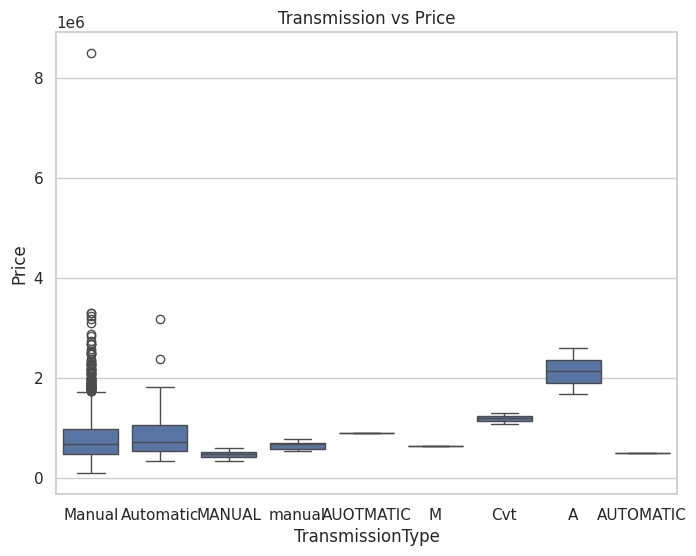

In [31]:
#Transmission Analysis
plt.figure(figsize=(8,6))
sns.boxplot(x=df['TransmissionType'],y=df['Price'])
plt.title("Transmission vs Price")

plt.show()

Automatic transmission cars generally have higher resale prices than manual transmission cars.

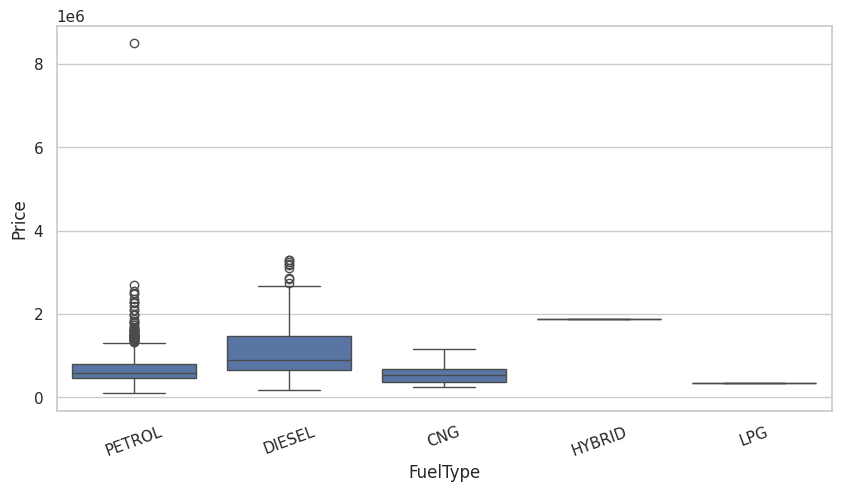

In [32]:
#Fuel Type Analysis
plt.figure(figsize=(10,5))
sns.boxplot(
    x=df['FuelType'],y=df['Price']
)
plt.xticks(rotation=20)
plt.show()

Fuel type influences resale prices, with some fuel types commanding higher market values than others.

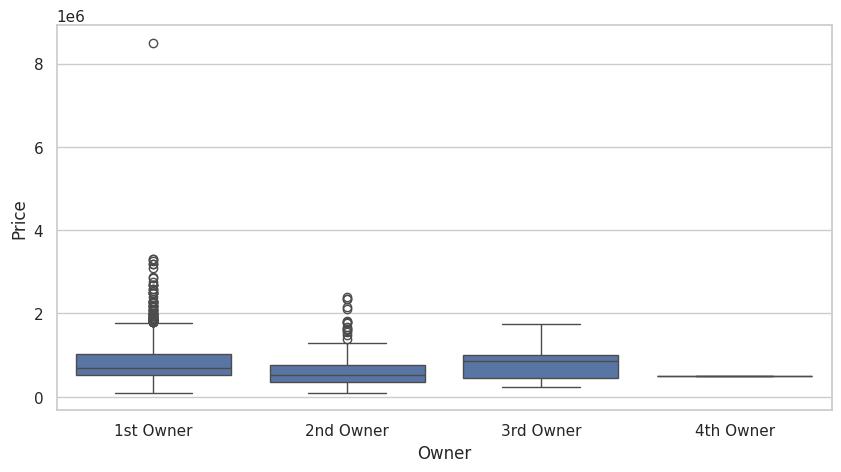

In [33]:
#Owner Analysis
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Owner'],y=df['Price'])
plt.show()

Cars with fewer previous owners generally have higher resale prices.

In [34]:
#FEATURE ENGINEERING

In [35]:
#Mileage Per Year
df["MileagePerYear"]=(df['Kilometer']/(df['CarAge']+1))

In [36]:
#Automatic Transmission
df["IsAutomatic"]=np.where(
    df["TransmissionType"]=="Automatic",1,0
)

In [37]:
#luxury brand features
luxury_brands = [
    "BMW",
    "Mercedes",
    "Audi",
    "Jaguar",
    "Volvo",
    "Lexus",
    "Land Rover",
    "Mini"
]
df["LuxuryBrand"]=df['Company'].isin(luxury_brands).astype(int)


In [38]:
#Vehicle Age Group
def age_group(age):

    if age <=3:
        return "New"

    elif age <=7:
        return "Medium"

    else:
        return "Old"

df["VehicleAgeGroup"] = df["CarAge"].apply(age_group)

In [39]:
#Warranty Available
if "Warranty" in df.columns:

    df["Warranty"] = (
        df["Warranty"]
        .replace({
            "Yes":1,
            "No":0
        })
    )

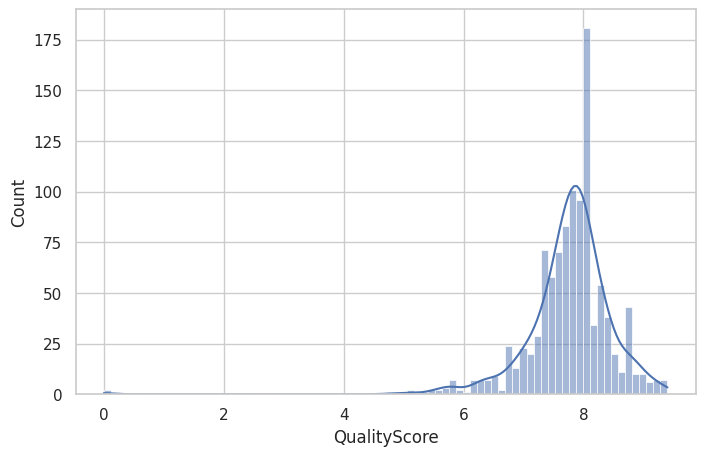

In [40]:
#Quality Score Distribution
if "QualityScore" in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df["QualityScore"],
        kde=True
    )

    plt.show()

Most vehicles have moderate to high quality scores, indicating generally good vehicle conditions.

In [41]:
#Outlier Removal

Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)

IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[
    (df['Price']>=lower)&
    (df['Price']<=upper)
]
print(df.shape)

(979, 19)


In [42]:
#prepare data for Modelling
X=df.drop('Price',axis=1)
y=df['Price']

In [43]:
#One hot encoding
X=pd.get_dummies(
    X,
    drop_first=True
)


In [44]:
print("Shape:",X.shape)

Shape: (979, 338)


In [45]:
constant_cols = [col for col in X.columns if X[col].nunique()==1]

print("Constant Columns :", len(constant_cols))

X.drop(columns=constant_cols, inplace=True)

print(X.shape)

Constant Columns : 0
(979, 338)


Constant features are removed to eliminate non-informative variables and simplify the model.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [47]:
#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Ridge Regression

In [48]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)

In [49]:
ridge.fit(X_train_scaled,y_train)

Ridge()

In [50]:
y_pred=ridge.predict(X_test_scaled)

In [51]:
ridge_mae=mean_absolute_error(y_test,y_pred)

In [52]:
ridge_mae

98345.80614083546

In [53]:
ridge_rmse=root_mean_squared_error(y_test,y_pred)

In [54]:
ridge_rmse

147368.3128023031

In [55]:
ridge_r2=r2_score(y_test,y_pred)

In [56]:
ridge_r2

0.8053325823173575

In [57]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    ridge,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)
print("CV Mean:", cv_scores.mean())
print("CV Std:", cv_scores.std())

Cross Validation Scores: [0.80367142 0.77987359 0.73925305 0.69222693 0.7682838 ]
CV Mean: 0.7566617599752383
CV Std: 0.03831104216984976


# Decision Tree

In [58]:
dt=DecisionTreeRegressor(random_state=42)

In [59]:
dt.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [60]:
dt_pred=dt.predict(X_test)

In [61]:
dt_mae=mean_absolute_error(y_test,dt_pred)

In [62]:
dt_mae

170908.16326530612

In [63]:
dt_rmse=root_mean_squared_error(y_test,dt_pred)

In [64]:
dt_rmse

259201.22590413046

In [65]:
dt_r2=r2_score(y_test,dt_pred)

In [66]:
dt_r2

0.39777449071761084

In [67]:
dt_cv = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Decision Tree CV Scores :", dt_cv)
print("Decision Tree CV Mean :", dt_cv.mean())
print("Decision Tree CV Std :", dt_cv.std())

Decision Tree CV Scores : [0.63990801 0.39726461 0.54913987 0.4891211  0.57869217]
Decision Tree CV Mean : 0.5308251509869473
Decision Tree CV Std : 0.08258740640211905


# Random Forest


In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
rf=RandomForestRegressor()

In [70]:
param={'n_estimators':[50,100,150,200],'bootstrap':[True,False],'max_depth':[3,5,7,9]}

In [71]:
gsc=GridSearchCV(estimator=rf,param_grid=param,scoring='r2')

In [72]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='r2')

In [73]:
gsc.best_params_

{'bootstrap': True, 'max_depth': 9, 'n_estimators': 150}

In [74]:
rf_pred=gsc.best_estimator_.predict(X_test)

In [75]:
rf_mae=mean_absolute_error(y_test,rf_pred)

In [76]:
rf_mae

134843.94903160218

In [77]:
rf_rmse=root_mean_squared_error(y_test,rf_pred)

In [78]:
rf_rmse

196084.92238606364

In [79]:
rf_r2=r2_score(y_test,rf_pred)

In [80]:
rf_r2

0.6553538381237493

In [81]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest CV Scores :", rf_cv)
print("Random Forest CV Mean :", rf_cv.mean())
print("Random Forest CV Std :", rf_cv.std())

Random Forest CV Scores : [0.76401728 0.73212449 0.74189062 0.71056623 0.74030994]
Random Forest CV Mean : 0.7377817122639354
Random Forest CV Std : 0.017229430542810835


# XGBoost

In [82]:
xgb=XGBRegressor()

In [83]:
params={'n_estimators':[50,100,150,200],'learning_rate':[0.15,0.20,0.25,0.30],'min_child_weight':[3,6,9,12],'max_depth':[3,5,7,9]}

In [84]:
gsc=GridSearchCV(estimator=xgb,param_grid=params,scoring='r2')

In [85]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learn...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.15, 0.2, 0.25, 0.3],
                         'max_depth': [3, 5, 7, 9],
                         'min_child_weight': [3, 6, 9, 12],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='r2')

In [86]:
gsc.best_params_

{'learning_rate': 0.2,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 200}

In [87]:
xgb_pred=gsc.best_estimator_.predict(X_test)

In [88]:
xgb_mae=mean_absolute_error(y_test,xgb_pred)

In [89]:
xgb_mae

113539.4577487245

In [90]:
xgb_rmse=root_mean_squared_error(y_test,xgb_pred)

In [91]:
xgb_rmse

170881.92988428895

In [92]:
xgb_r2=r2_score(y_test,xgb_pred)

In [93]:
xgb_r2

0.7382556441872687

In [94]:
xgb_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("XGBoost CV Scores :", xgb_cv)
print("XGBoost CV Mean :", xgb_cv.mean())
print("XGBoost CV Std :", xgb_cv.std())

XGBoost CV Scores : [0.79223683 0.79245897 0.75692115 0.7087457  0.7555925 ]
XGBoost CV Mean : 0.7611910322396374
XGBoost CV Std : 0.0307948520329673


# Model Comparision

In [102]:
results=pd.DataFrame({
    "Model":[
        "Ridge Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE":[
        ridge_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE":[
        ridge_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2":[
        ridge_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ],
     "CV Mean":[
        cv_scores.mean(),
        dt_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean()
    ],
    "CV Std":[
        cv_scores.std(),
        dt_cv.std(),
        rf_cv.std(),
        xgb_cv.std()
    ]
})

results = results.sort_values(
    by=["R2", "CV Mean"],
    ascending=False
)

results

,Model,MAE,RMSE,R2,CV Mean,CV Std
0,Ridge Regression,98345.806141,147368.312802,0.805333,0.756662,0.038311
3,XGBoost,113539.457749,170881.929884,0.738256,0.761191,0.030795
2,Random Forest,134843.949032,196084.922386,0.655354,0.737782,0.017229
1,Decision Tree,170908.163265,259201.225904,0.397774,0.530825,0.082587


Although XGBoost achieved a slightly higher average cross-validation score, Ridge Regression delivered the best performance on the independent test set with the lowest prediction error. Therefore, I selected Ridge Regression as the final model.

# Visualize Comparision

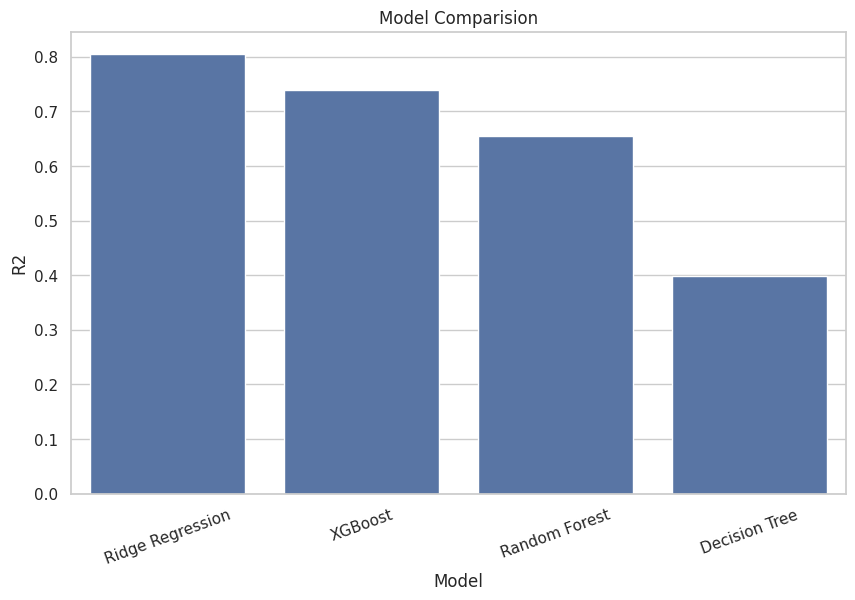

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)
plt.title("Model Comparision")
plt.xticks(rotation=20)
plt.show()

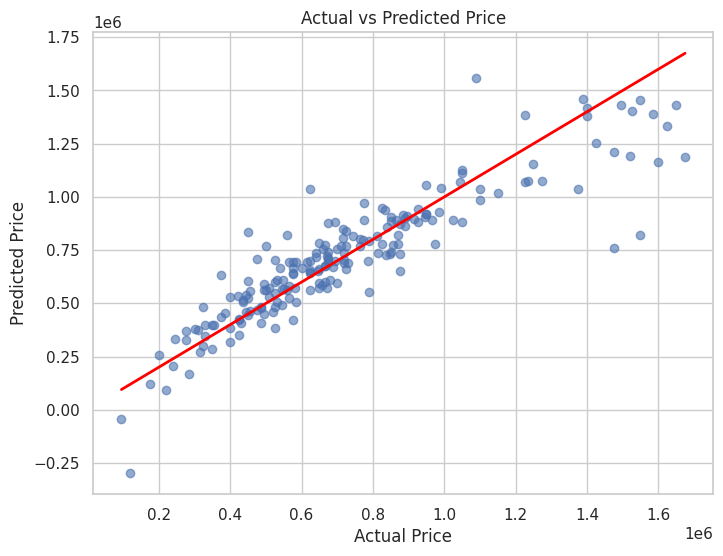

In [98]:
#Actual vs Predicted Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

Shows how close your predictions are to the actual prices

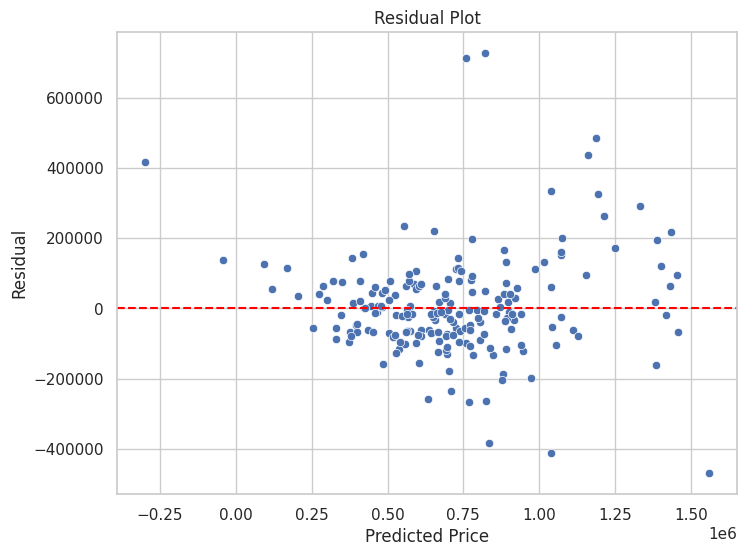

In [99]:
#Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Checks whether errors are randomly distributed.

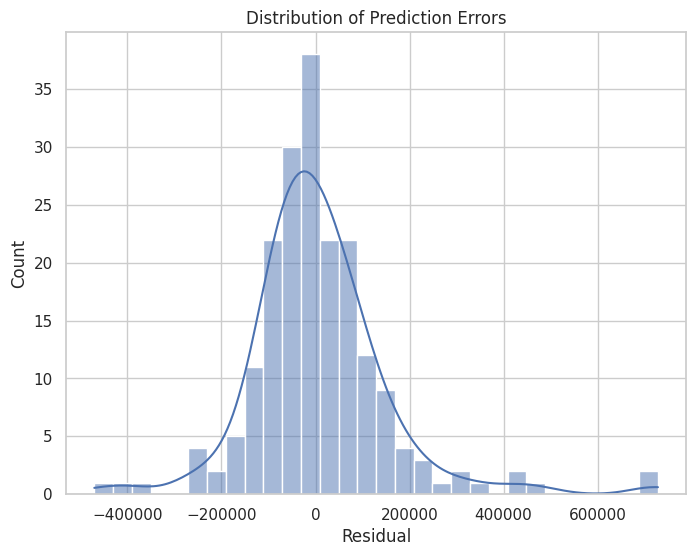

In [100]:
#Error Distribution
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.show()

# save model

In [101]:
import joblib
joblib.dump(ridge, "used_car_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Conclusion

Ridge Regression achieved the highest test performance
with an R² score of 0.8053, making it the best-performing model.
XGBoost achieved the highest average cross-validation score (0.7612), indicating strong generalization.
Random Forest produced consistent results but lower predictive accuracy.
Decision Tree showed the weakest performance among the evaluated models.
Based on overall performance and prediction accuracy, Ridge Regression was selected as the final model for used car price prediction.